# Exploratory Data Analysis — Heart Disease (Cleveland)

**Dataset:** UCI Heart Disease — Cleveland subset (303 patients, 13 features + binary target)
**Task:** Binary classification — predict presence of heart disease (1) vs absence (0)
**Source file:** `raw_data/heart+disease/processed.cleveland.data`

All plots are saved to `../reports/figures/` for inclusion in the final report.

## 1. Setup — Imports and Constants

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

DATA_PATH = '../raw_data/heart+disease/processed.cleveland.data'
FIG_DIR = '../reports/figures'
os.makedirs(FIG_DIR, exist_ok=True)

COLUMN_NAMES = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target',
]

Matplotlib is building the font cache; this may take a moment.


## 2. Load Dataset

Raw UCI file has no header row, uses `?` for missing values, and target is 0–4 (severity). We supply column names, convert `?` to NaN, and binarize the target to 0/1.

In [2]:
df = pd.read_csv(DATA_PATH, header=None, names=COLUMN_NAMES, na_values='?')
df['target'] = (df['target'] > 0).astype(int)
print(f'Loaded {df.shape[0]} rows, {df.shape[1]} columns')

Loaded 303 rows, 14 columns


## 3. Initial Exploration — Shape, Columns, Types

In [3]:
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nData types:')
print(df.dtypes)

Shape: (303, 14)

Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object


In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 4. Missing Values

Cleveland has a small number of missing values, expected in `ca` and `thal`. We will impute these in the preprocessing pipeline (median for numeric).

In [5]:
print('Missing values per column:')
print(df.isnull().sum())

print('\nMissing percentage per column:')
print((df.isnull().mean() * 100).round(2))

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Missing percentage per column:
age         0.00
sex         0.00
cp          0.00
trestbps    0.00
chol        0.00
fbs         0.00
restecg     0.00
thalach     0.00
exang       0.00
oldpeak     0.00
slope       0.00
ca          1.32
thal        0.66
target      0.00
dtype: float64


## 5. Descriptive Statistics

Note the wildly different scales (chol in 100s, oldpeak in single digits) — motivates standardization in the preprocessing pipeline.

In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


## 6. Duplicate Rows

In [7]:
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 0


## 7. Outlier Sanity Check

Look for impossible values: cholesterol or resting blood pressure equal to zero.

In [8]:
print('Rows with chol == 0    :', (df['chol'] == 0).sum())
print('Rows with trestbps == 0:', (df['trestbps'] == 0).sum())

Rows with chol == 0    : 0
Rows with trestbps == 0: 0


## 8. Class Balance — Target Distribution

Cleveland is roughly balanced (~54% no disease / ~46% disease) — no need for class weighting.

target
0    164
1    139
Name: count, dtype: int64

Proportions:
target
0    0.541
1    0.459
Name: proportion, dtype: float64


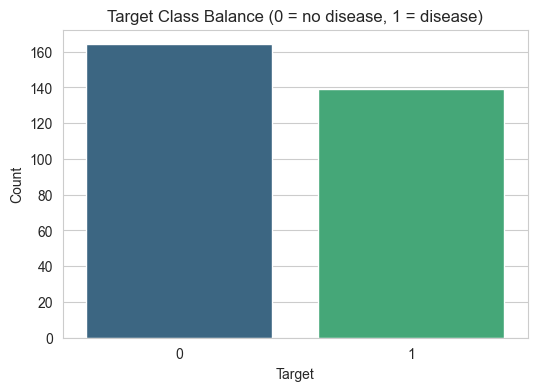

In [9]:
print(df['target'].value_counts())
print('\nProportions:')
print(df['target'].value_counts(normalize=True).round(3))

plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, hue='target', palette='viridis', legend=False)
plt.title('Target Class Balance (0 = no disease, 1 = disease)')
plt.xlabel('Target')
plt.ylabel('Count')
plt.savefig(f'{FIG_DIR}/class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Univariate — Histograms of All Numeric Features

Look for skewness, multimodality, and discrete-vs-continuous distinctions.

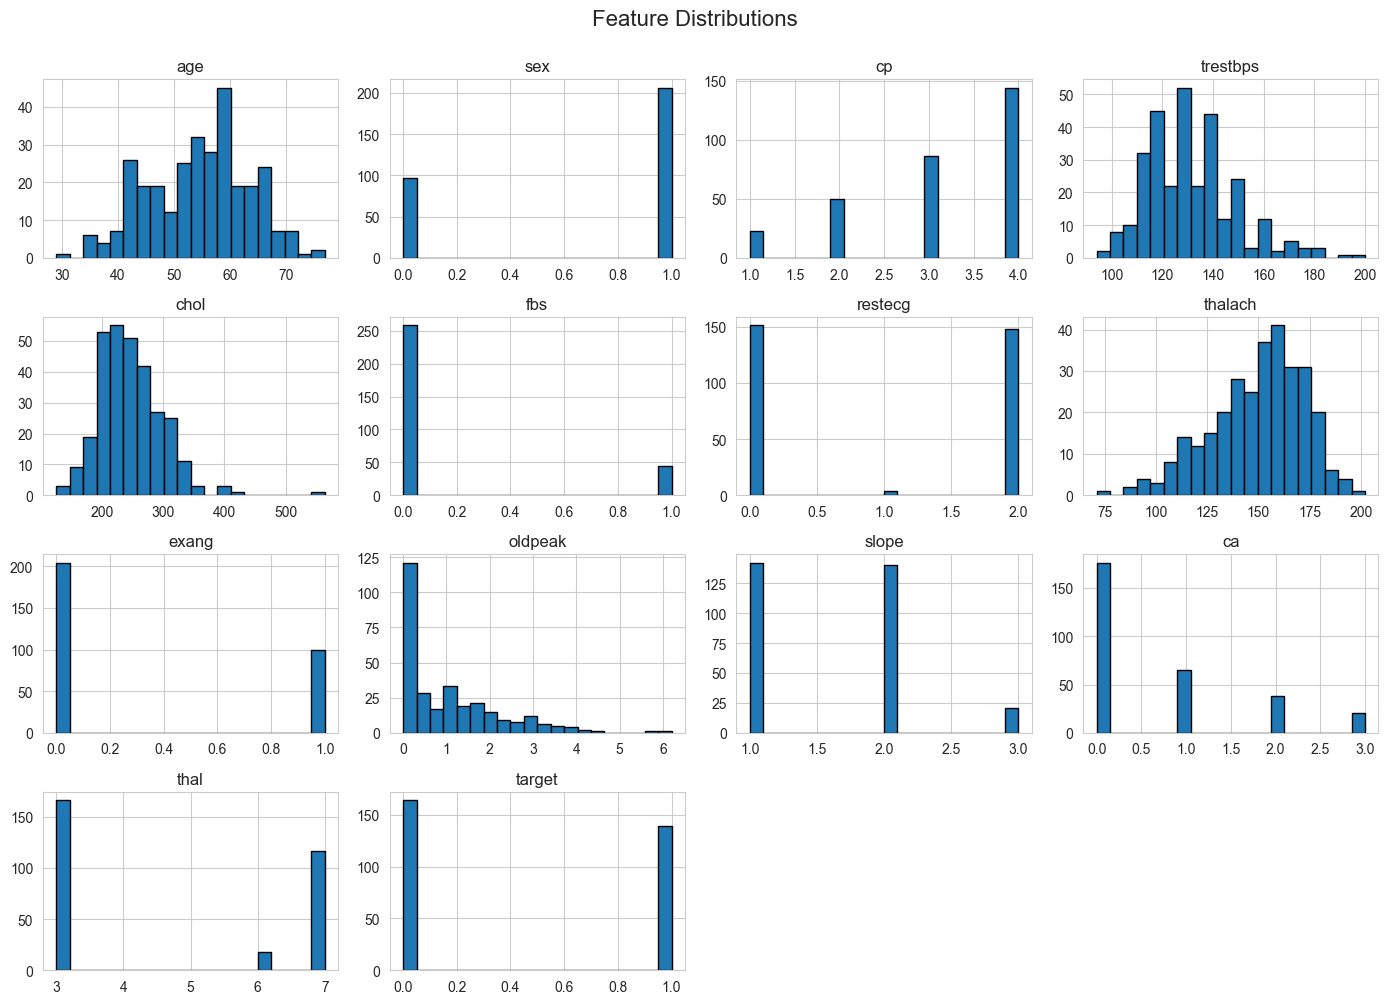

In [10]:
df.hist(figsize=(14, 10), bins=20, edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=16, y=1.00)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/feature_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Bivariate — Feature Distributions by Target Class

Boxplots comparing each numeric feature between healthy (0) and diseased (1) patients. Features with clearly different distributions are likely strong predictors.

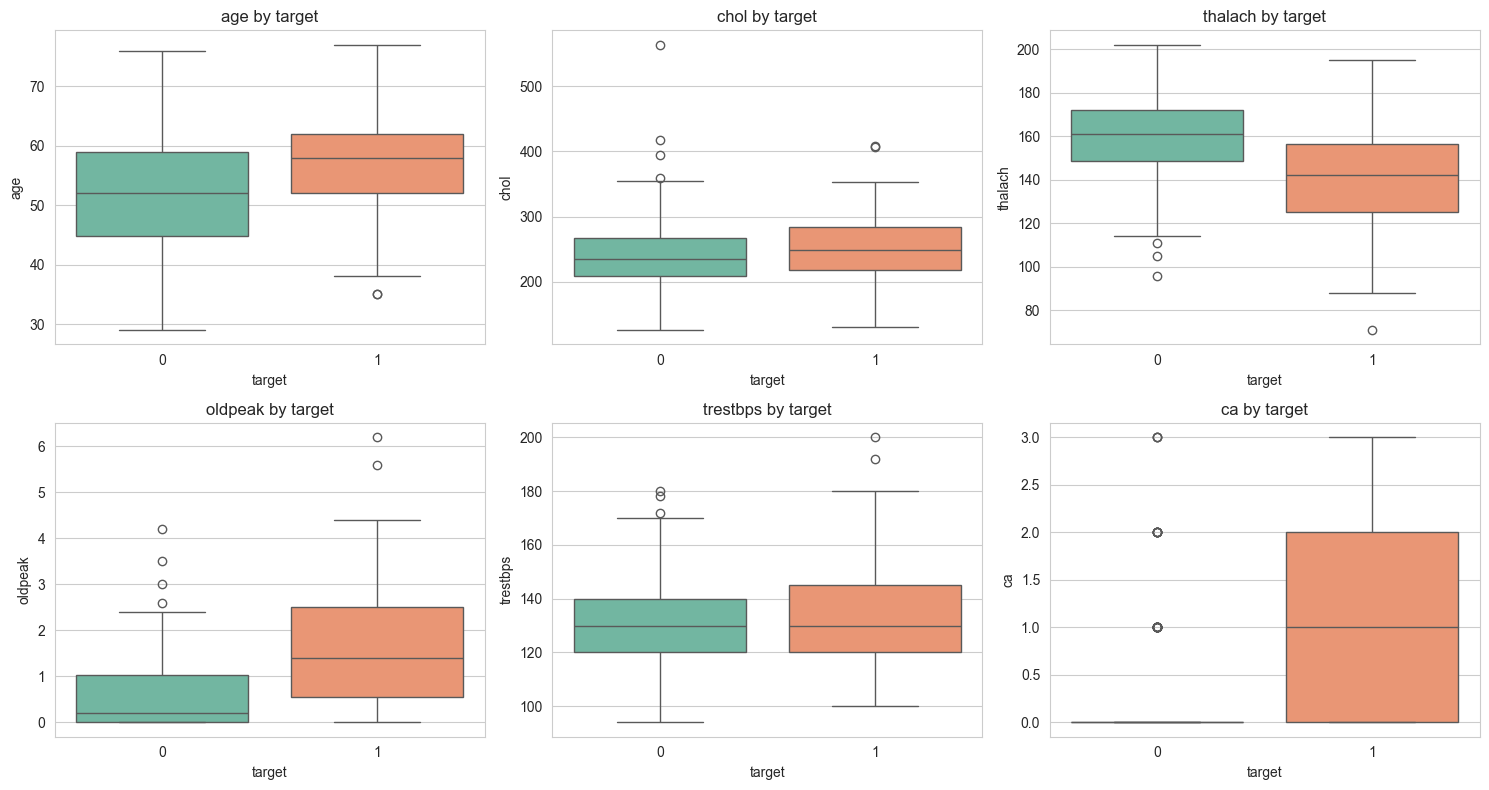

In [11]:
features = ['age', 'chol', 'thalach', 'oldpeak', 'trestbps', 'ca']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flat, features):
    sns.boxplot(x='target', y=feat, data=df, ax=ax, hue='target',
                palette='Set2', legend=False)
    ax.set_title(f'{feat} by target')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/boxplots_by_target.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Correlation Heatmap

Pearson correlation across all features and target. Helps spot strong predictors (features highly correlated with target) and redundancies (features highly correlated with each other).

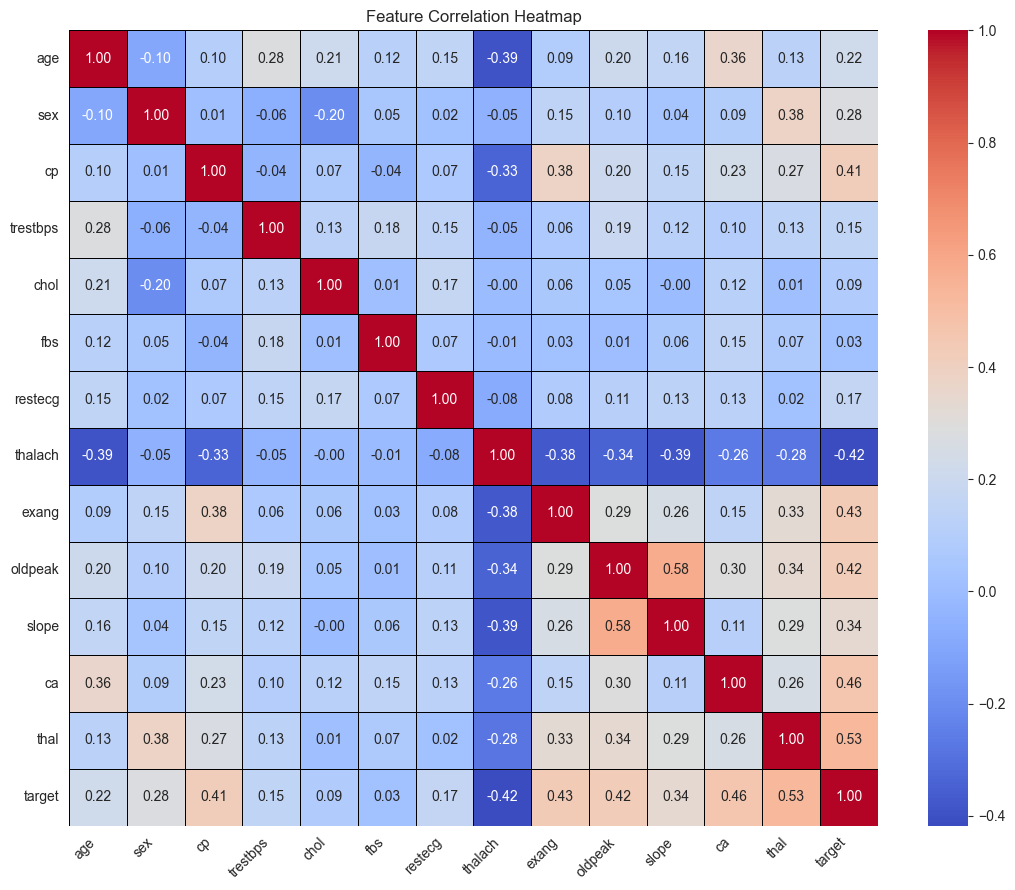


Correlation with target (sorted):
thal        0.525689
ca          0.460442
exang       0.431894
oldpeak     0.424510
cp          0.414446
slope       0.339213
sex         0.276816
age         0.223120
restecg     0.169202
trestbps    0.150825
chol        0.085164
fbs         0.025264
thalach    -0.417167
Name: target, dtype: float64


In [12]:
corr = df.corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, linecolor='black', cbar=True)
plt.title('Feature Correlation Heatmap')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCorrelation with target (sorted):')
print(corr['target'].drop('target').sort_values(ascending=False))

## 12. EDA Findings & Modeling Decisions

**Findings:**
- Dataset shape: **303 rows × 14 columns** (13 features + binary target)
- Target balance: **54.13% class 0** vs **45.87% class 1** → roughly **balanced** (no class weighting needed)
- Missing values: **6 total** — `ca` (4), `thal` (2); all other columns complete
- Duplicates: **0**
- Outliers detected: **none** — no `chol == 0` or `trestbps == 0` rows; describe() ranges are physiologically plausible
- Strongest positive correlations with target: **`thal` (0.53)**, **`ca` (0.46)**, **`exang` (0.43)**, **`oldpeak` (0.43)**, **`cp` (0.41)**
- Strongest negative correlation with target: **`thalach` (−0.42)** — lower max heart rate associates with disease
- Features on different scales? **Yes** — `chol` in 100s, `trestbps` ~130, `age` ~54, `oldpeak` ~1 → standardization required

**Decisions for next step (preprocessing):**
- Missing-value strategy: **median imputation** for `ca` and `thal` (small count, numeric-encoded)
- Categorical encoding: **one-hot encode** the nominal categoricals — `cp`, `restecg`, `slope`, `thal`
  (binary columns `sex`, `fbs`, `exang` are already 0/1 and can pass through)
- Scaling: **`StandardScaler`** on the continuous numeric features — `age`, `trestbps`, `chol`, `thalach`, `oldpeak`
  (fit on train only, applied via an sklearn `Pipeline` to prevent data leakage)
- Train/test split: **20% test**, **stratified on target**, **`random_state=42`**
- Model candidates (Task 2): Logistic Regression (baseline) and Random Forest (ensemble); compare with accuracy, precision, recall, F1, ROC-AUC